In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

zip_path = "/content/drive/MyDrive/power-line/cplid_yolo.zip"
print("Exists:", os.path.exists(zip_path))
print("Size:", os.path.getsize(zip_path) / 1e6, "MB")

Exists: True
Size: 408.548173 MB


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/power-line/cplid_yolo.zip"
extract_to = "/content/"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_to)

print("Extracted to:", extract_to)

Extracted to: /content/


In [ ]:
from pathlib import Path

root = Path("/content/cplid_yolo")

for split in ["train", "val"]:
    img_count = len(list((root / "images" / split).iterdir()))
    lbl_count = len(list((root / "labels" / split).iterdir()))
    print(f"{split}: {img_count} images, {lbl_count} labels")

print("\nYAML contents:")
print((root / "dataset.yaml").read_text())

train: 678 images, 678 labels
val: 170 images, 170 labels

YAML contents:
path: ../cplid_yolo
train: images/train
val: images/val

names:
  0: insulator
  1: defect



In [ ]:
yaml_content = """\
path: /content/cplid_yolo
train: images/train
val: images/val

names:
  0: insulator
  1: defect
"""

(root / "dataset.yaml").write_text(yaml_content)
print((root / "dataset.yaml").read_text())

path: /content/cplid_yolo
train: images/train
val: images/val

names:
  0: insulator
  1: defect



In [ ]:
!pip install ultralytics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import ultralytics
print("Ultralytics version:", ultralytics.__version__)

Ultralytics version: 8.4.83


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
GPU name: Tesla T4


In [ ]:
model = YOLO('yolov8n.pt')
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [ ]:
result = model.train(
    data="/content/cplid_yolo/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="cplid_yolov8n",
    patience=15,
    )

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cplid_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cplid_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [ ]:
from IPython.display import Image as IPImage

results_dir = "/content/runs/detect/cplid_yolov8n"
IPImage = (f"{results_dir}/results.png")

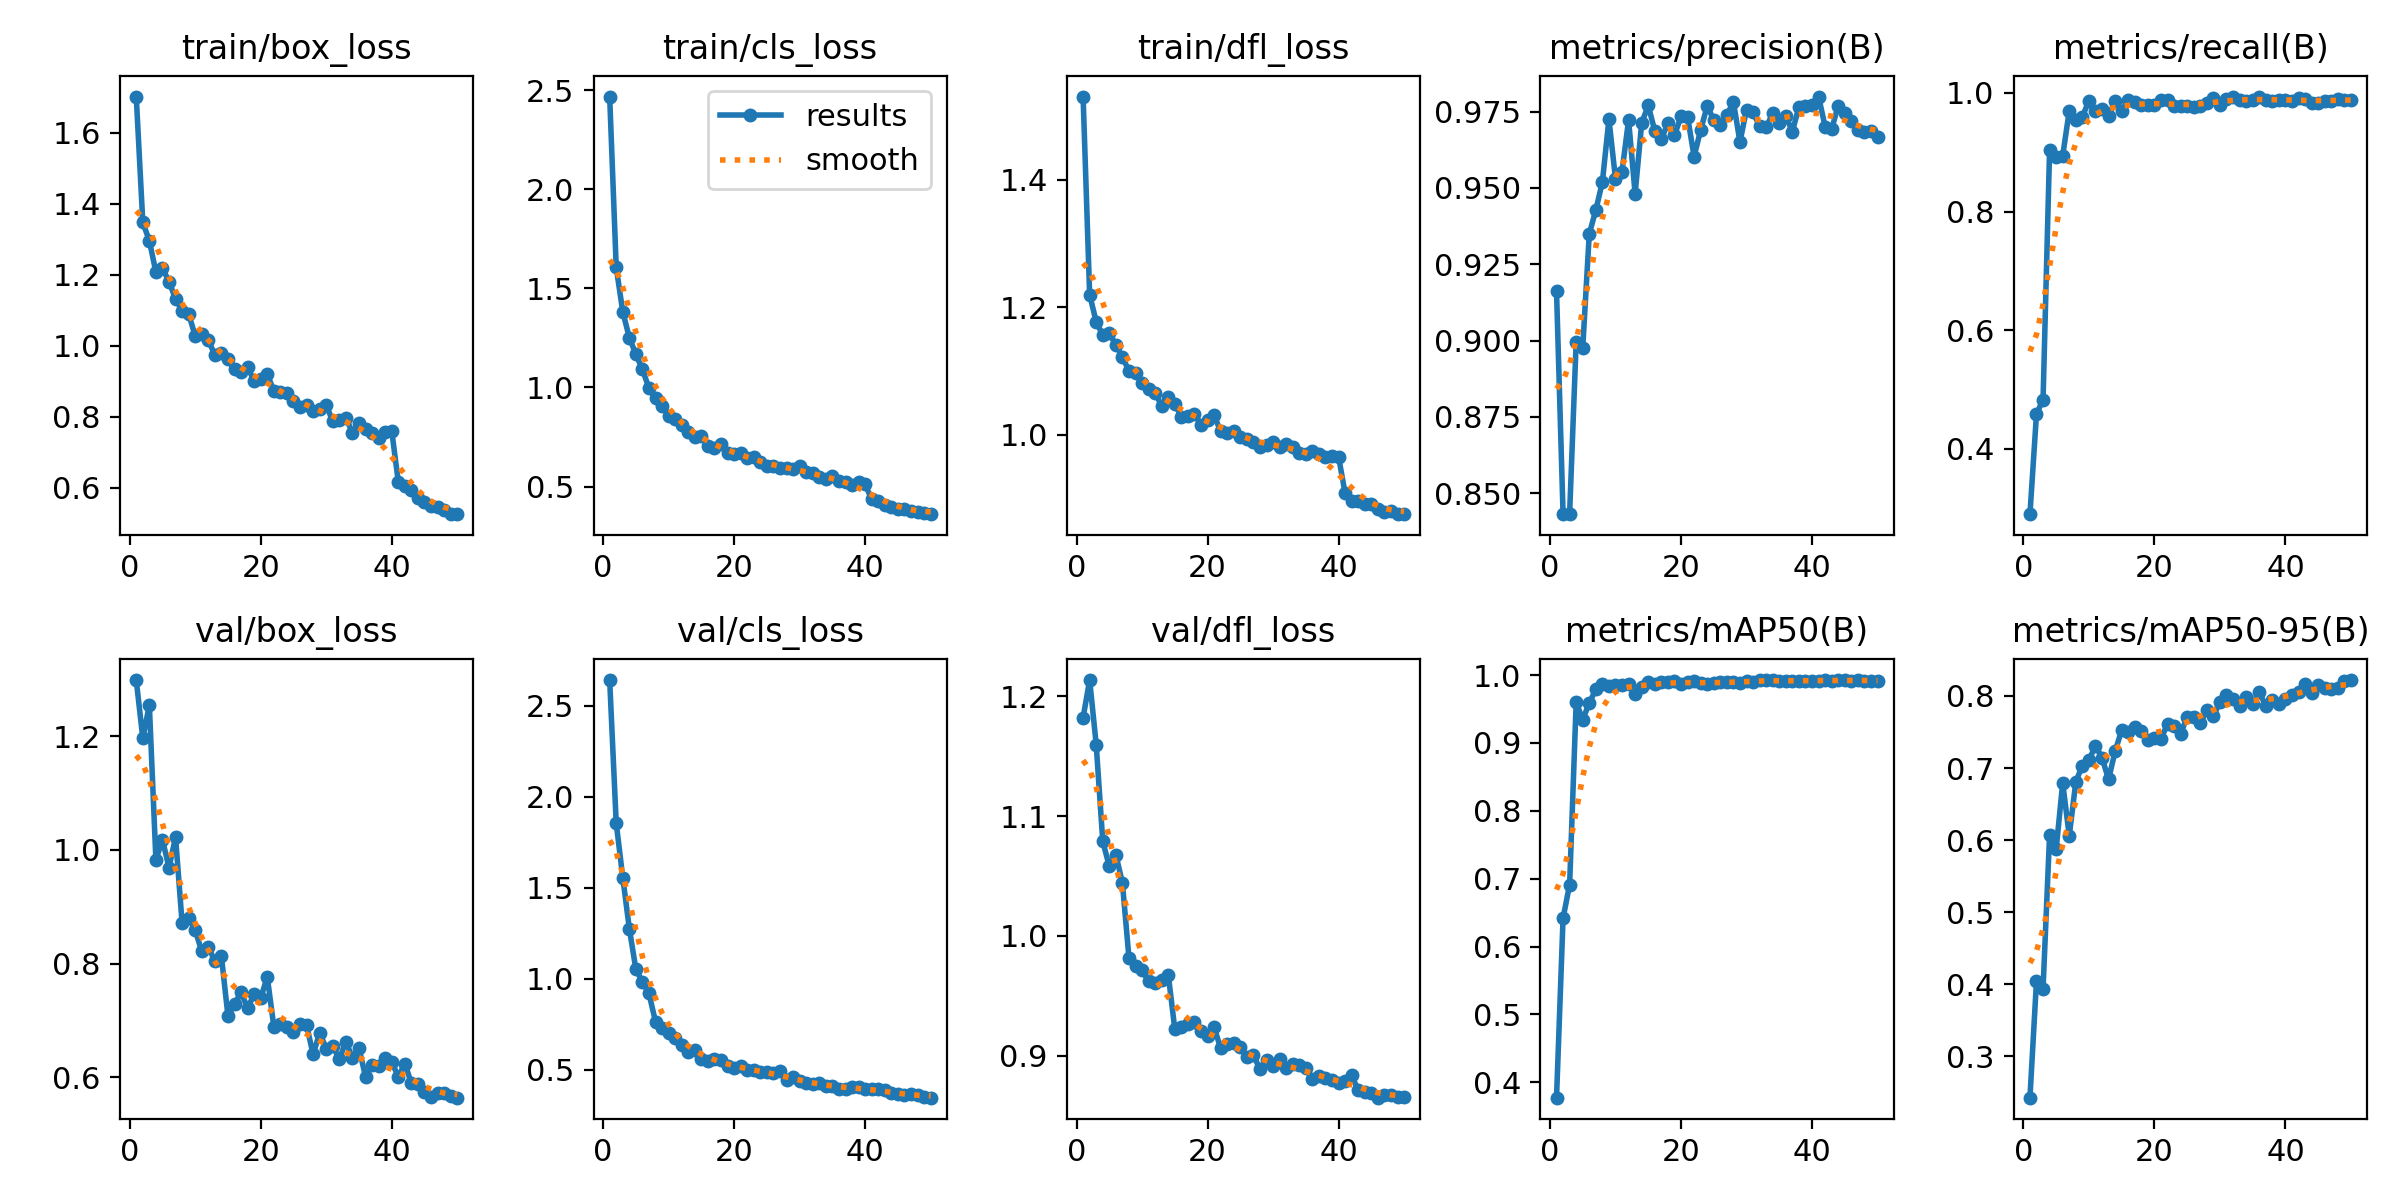

In [ ]:
from IPython.display import Image as IPImage, display

results_dir = "/content/runs/detect/cplid_yolov8n"
display(IPImage(f"{results_dir}/results.png"))

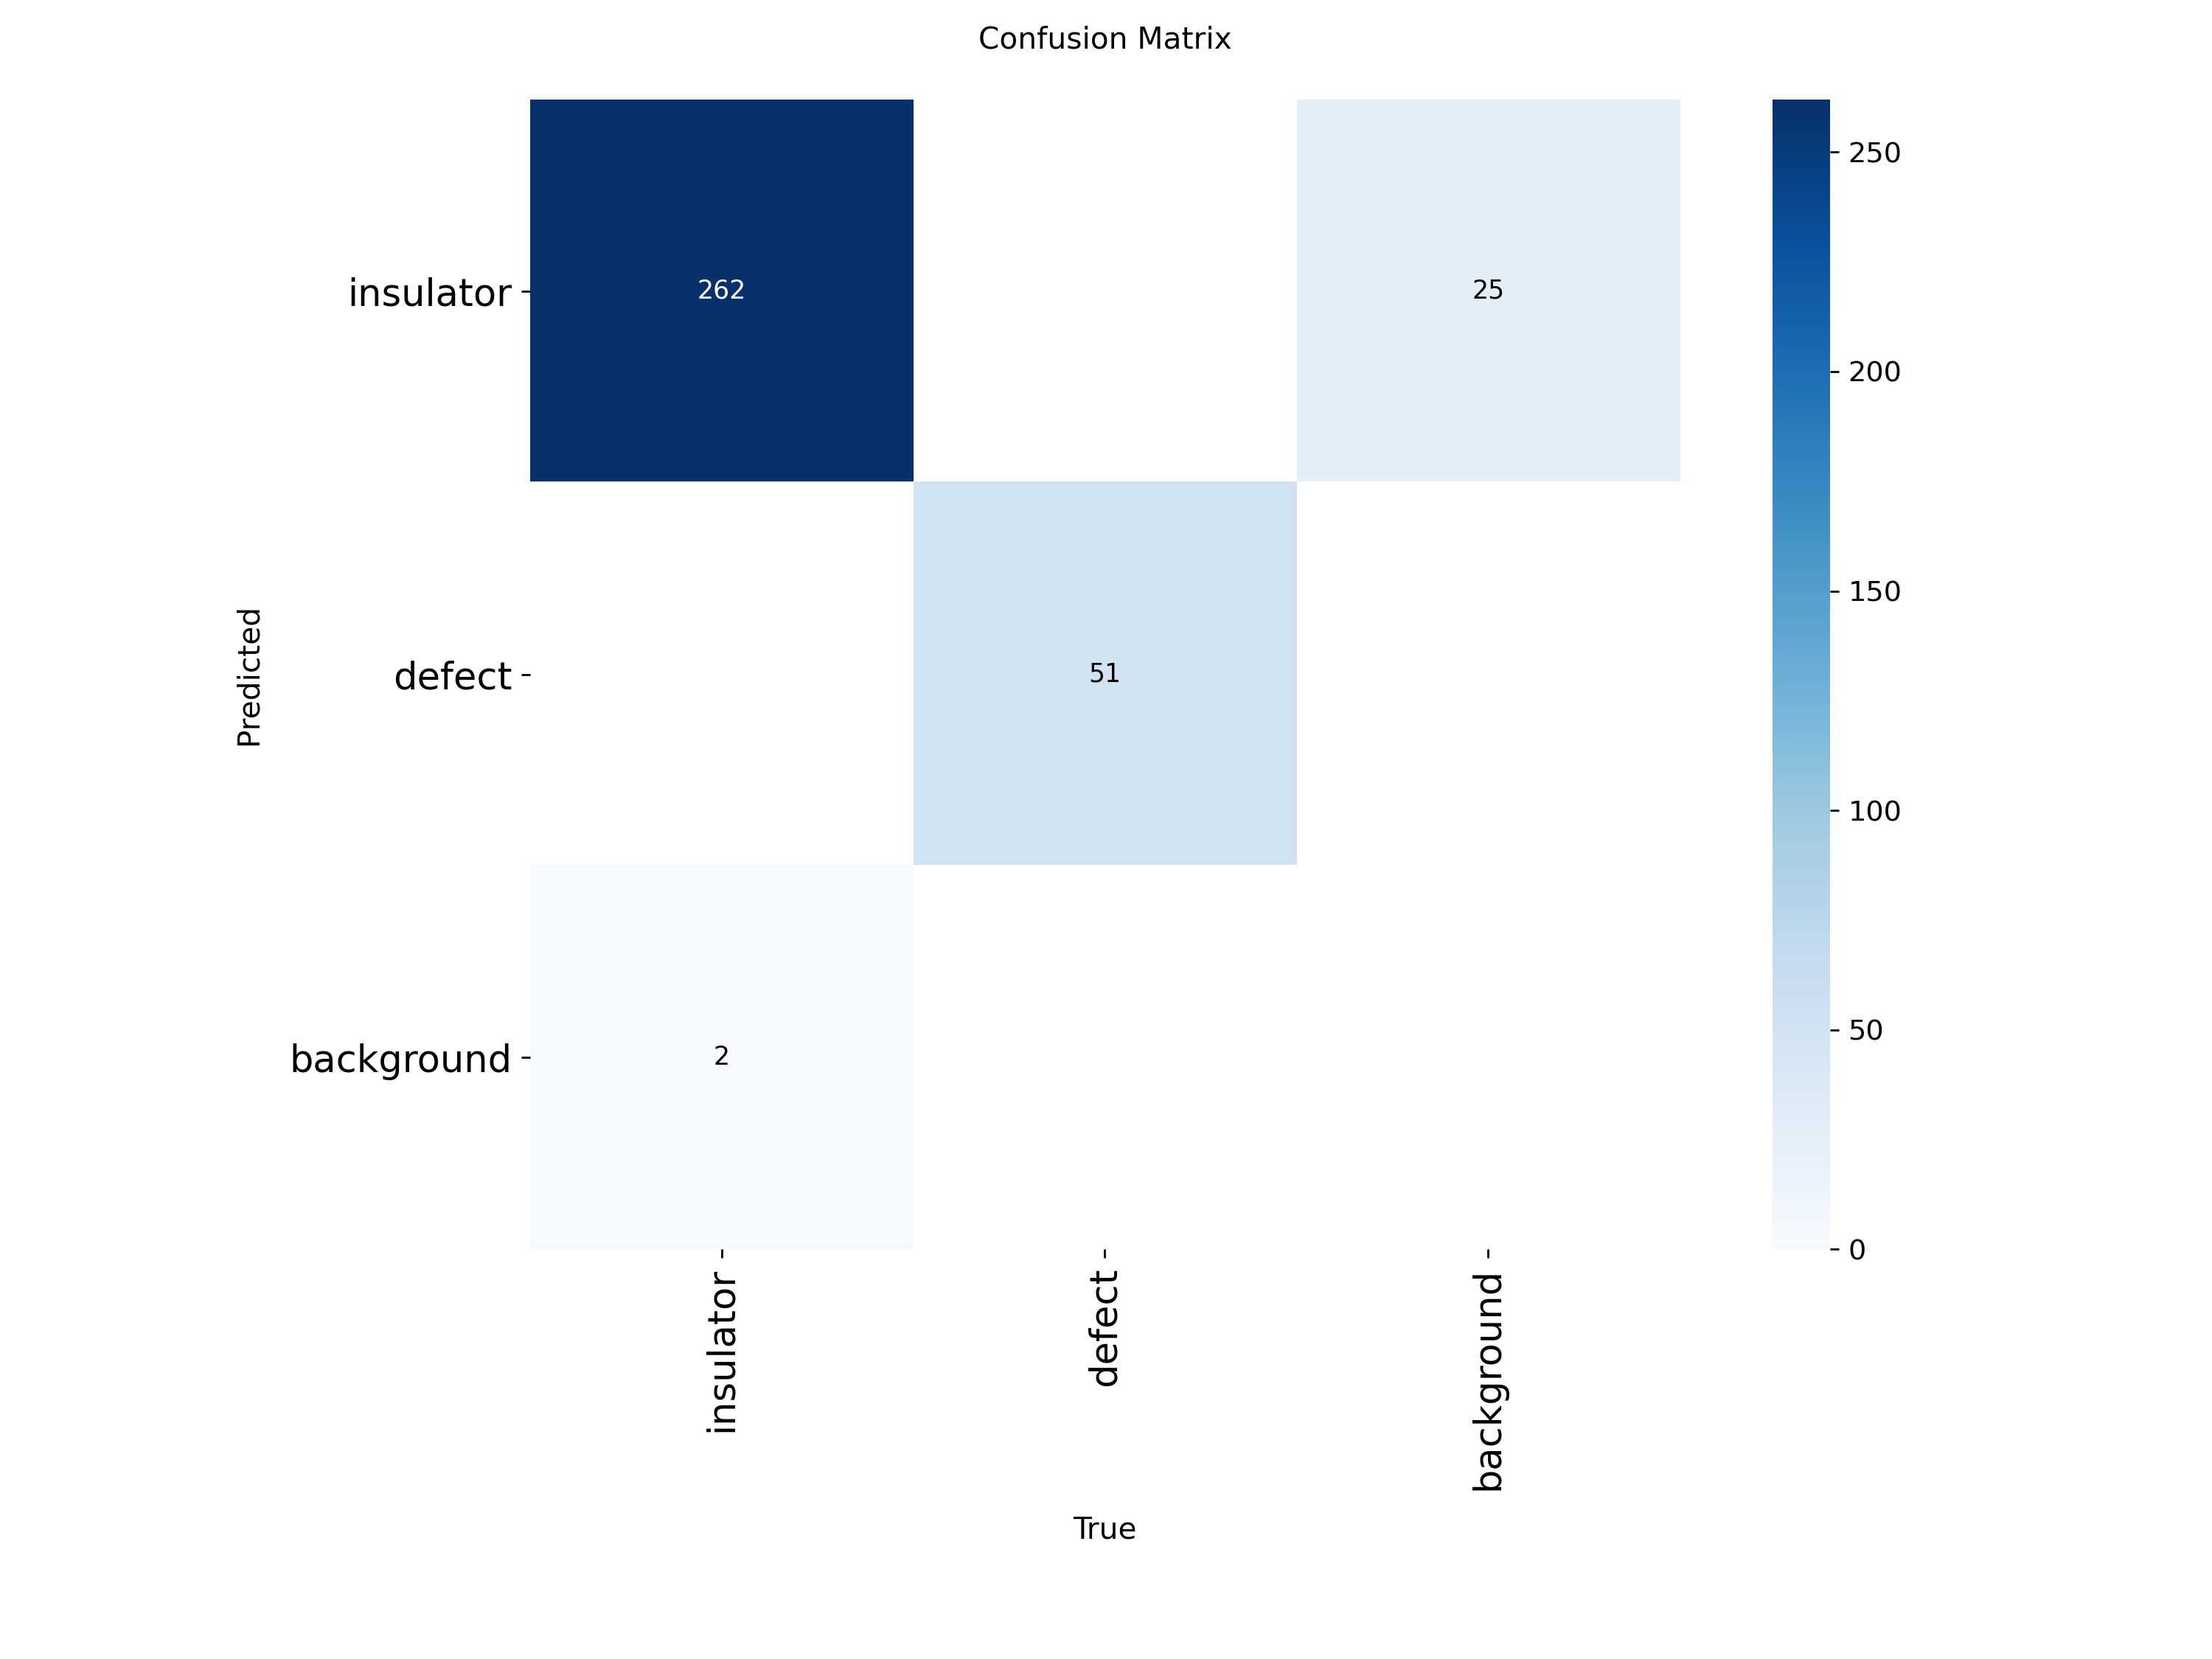

In [ ]:
display(IPImage(f"{results_dir}/confusion_matrix.png"))


0: 480x640 1 insulator, 1 defect, 21.1ms
1: 480x640 2 insulators, 21.1ms
2: 480x640 4 insulators, 21.1ms
3: 480x640 1 insulator, 1 defect, 21.1ms
4: 480x640 1 insulator, 21.1ms
5: 480x640 1 insulator, 1 defect, 21.1ms
Speed: 8.4ms preprocess, 21.1ms inference, 3.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/cplid_predictions
image0.jpg


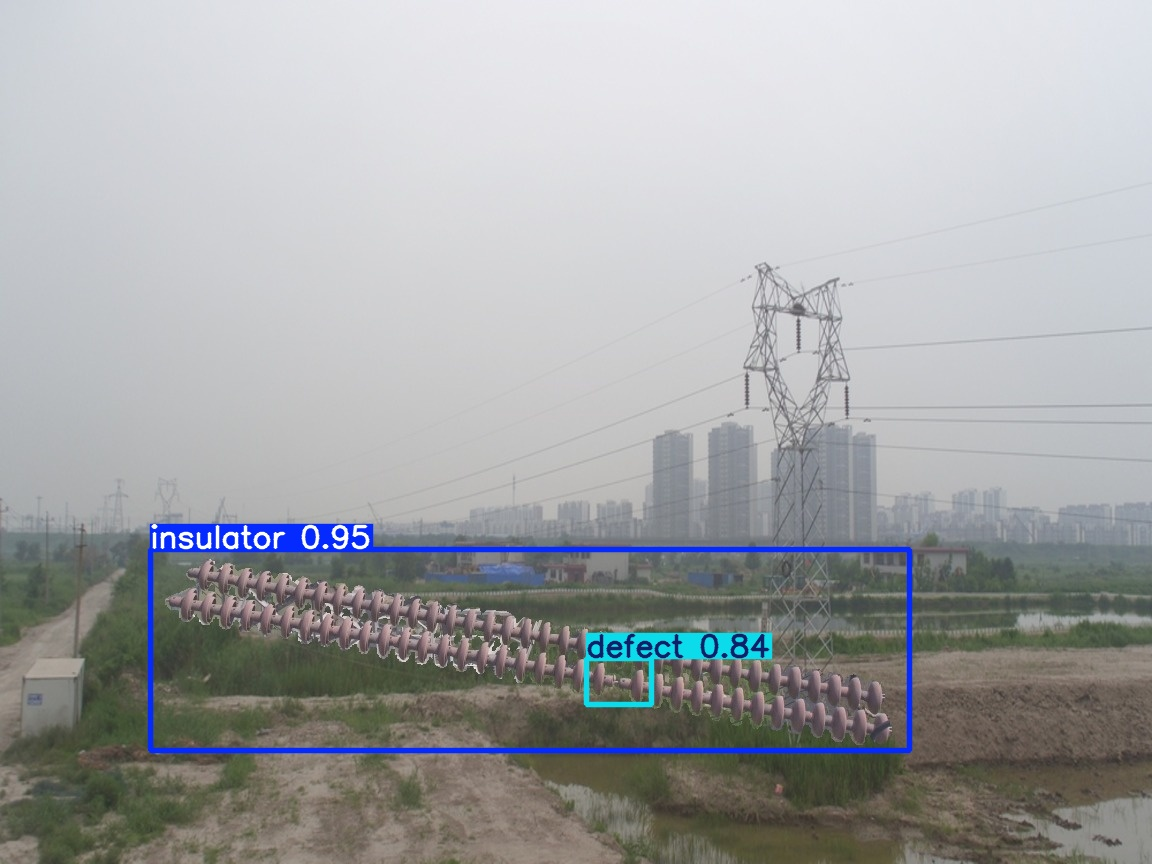

image1.jpg


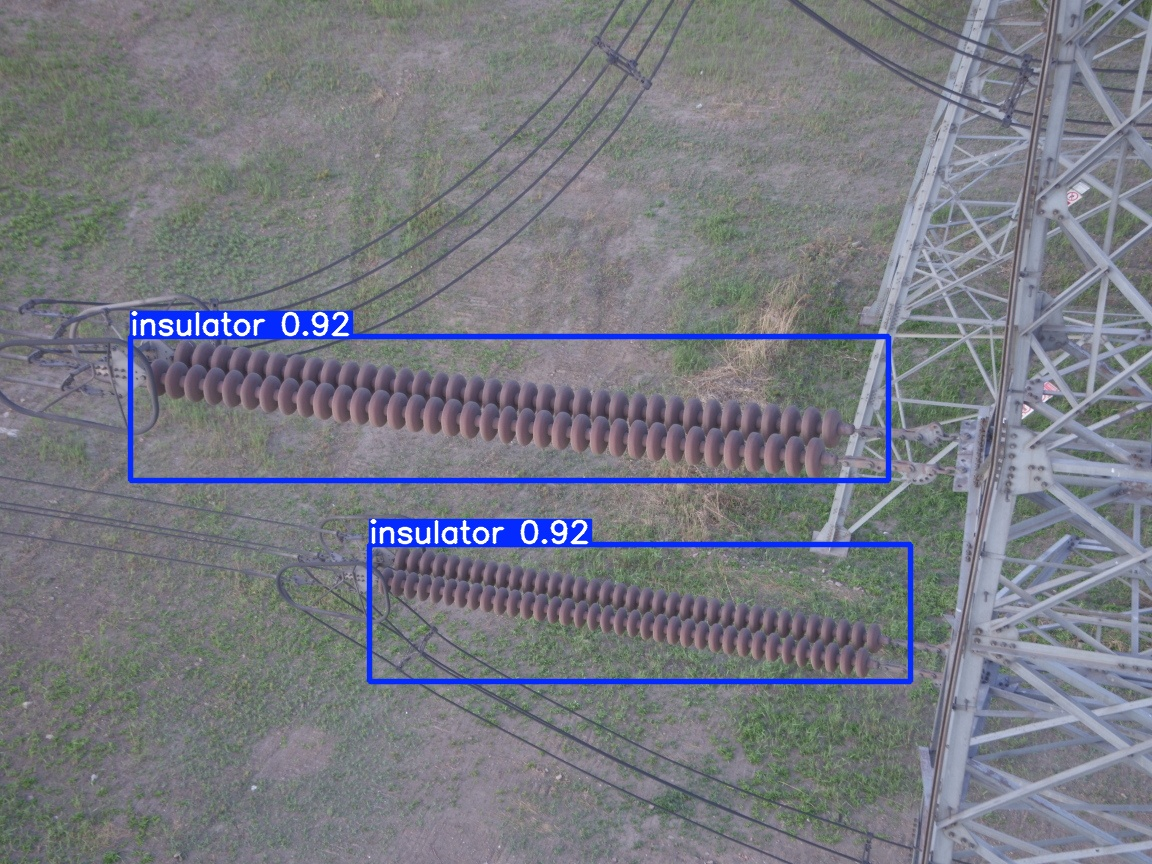

image2.jpg


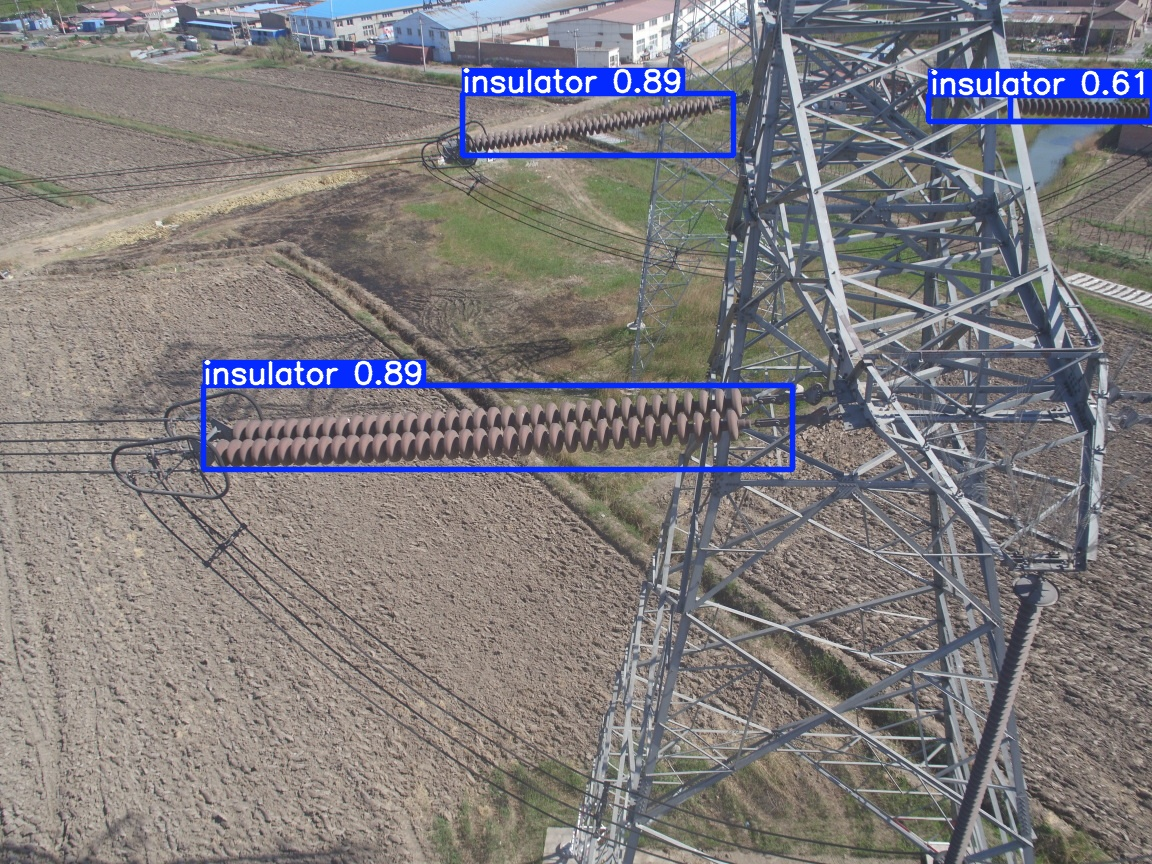

image3.jpg


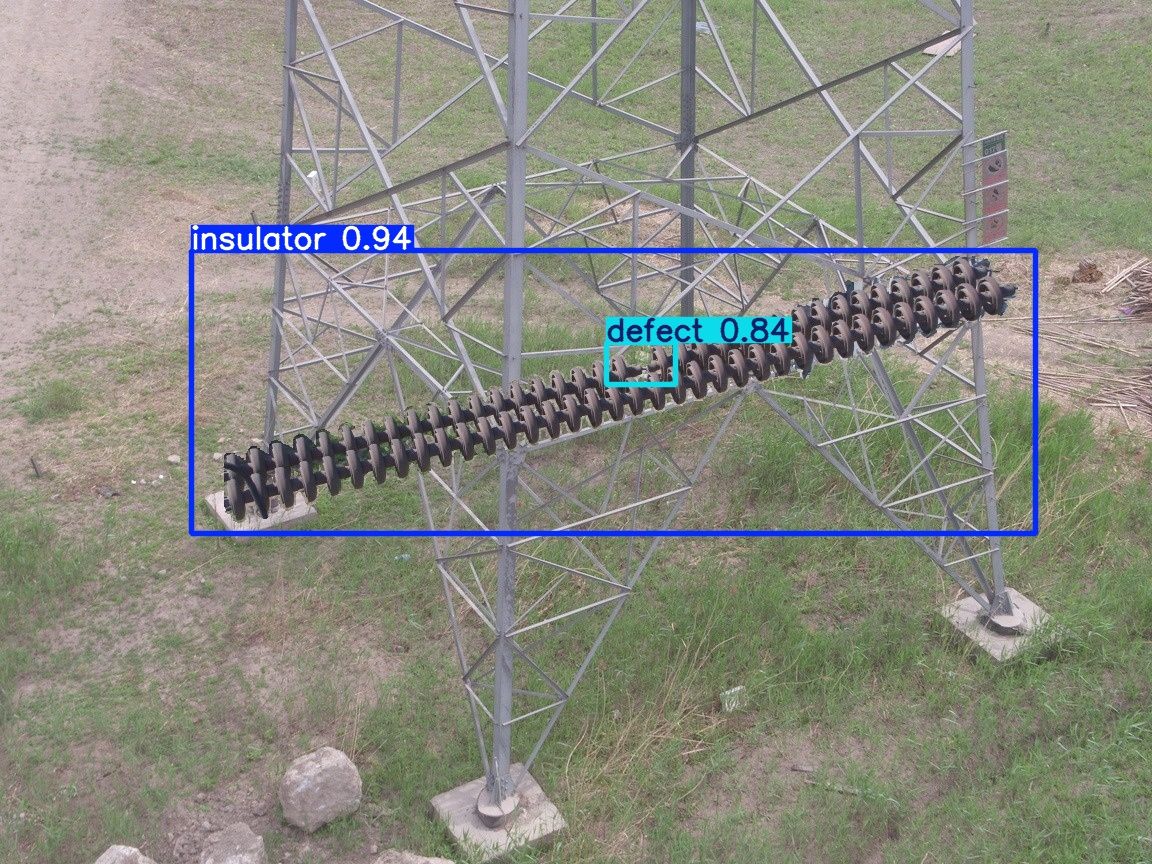

image4.jpg


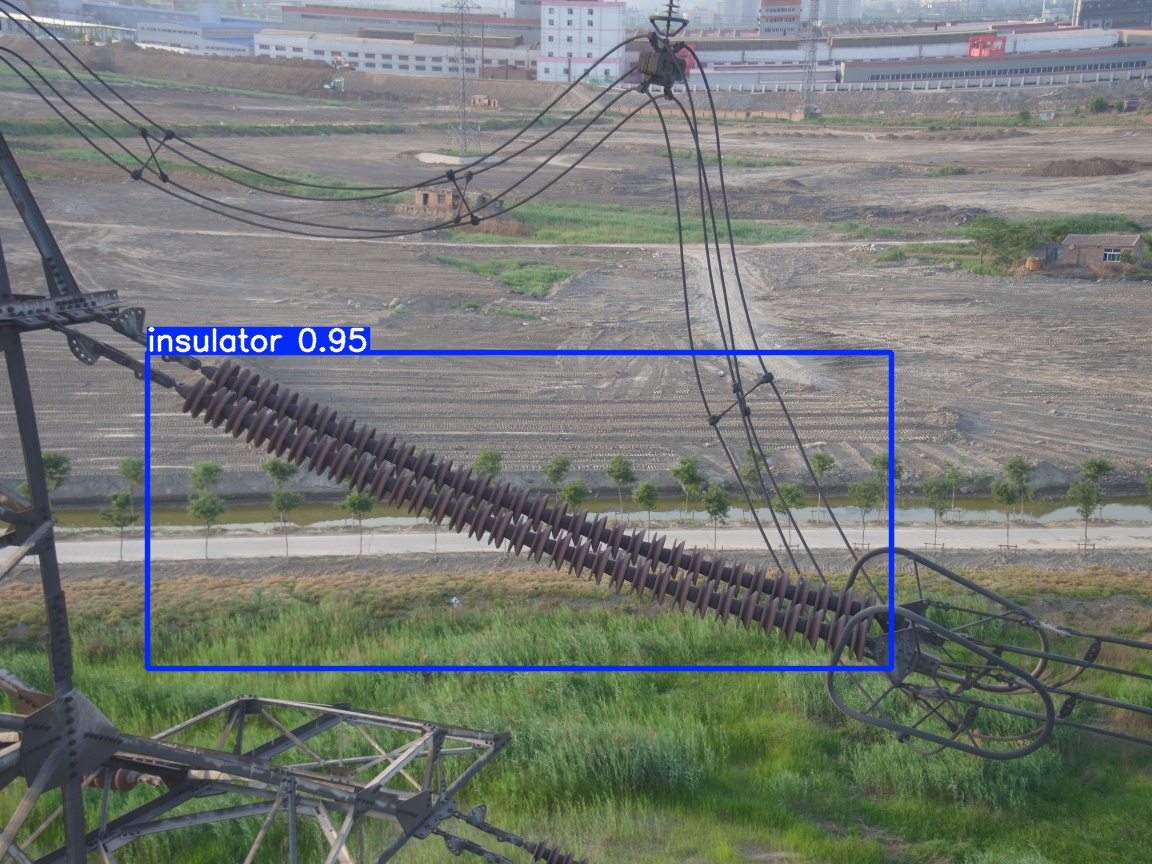

image5.jpg


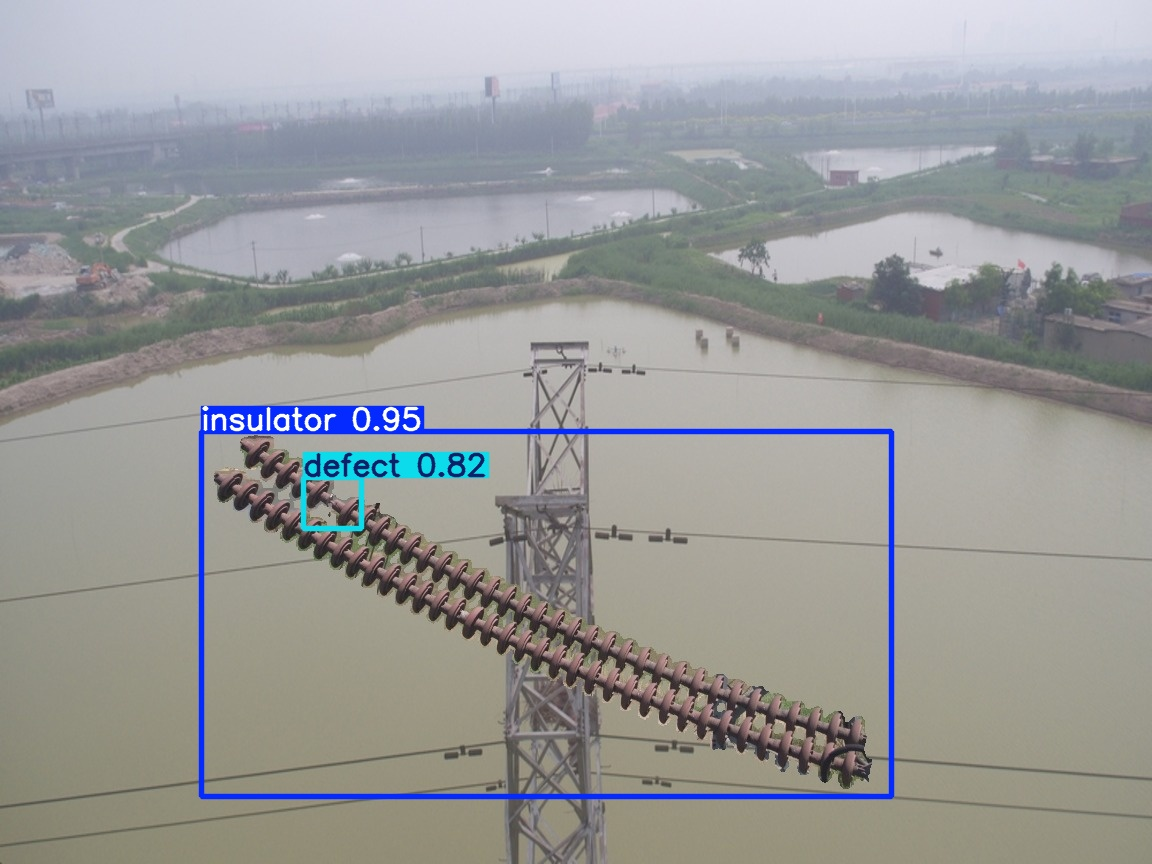

In [ ]:
import glob

# Pick a few validation images to predict on
val_images = sorted(glob.glob("/content/cplid_yolo/images/val/*.jpg"))[:6]

# Run inference
results = model.predict(
    source=val_images,
    conf=0.5,  # only keep detections with confidence > 50%
    save=True,
    project="/content/runs/detect",
    name="cplid_predictions",
    exist_ok=True,
)

# Display each predicted image
pred_dir = "/content/runs/detect/cplid_predictions"
for img_path in sorted(glob.glob(f"{pred_dir}/*.jpg"))[:6]:
    print(img_path.split("/")[-1])
    display(IPImage(img_path))

In [ ]:
import shutil

weights_src = "/content/runs/detect/cplid_yolov8n/weights/best.pt"
results_src = "/content/runs/detect/cplid_yolov8n"

# Save the best weights file to Drive
weights_dest = "/content/drive/MyDrive/power-line/cplid_yolov8n_best.pt"
shutil.copy(weights_src, weights_dest)
print(f"Saved weights to: {weights_dest}")

# Also zip the full training run (plots, metrics, configs) and save
runs_zip = shutil.make_archive(
    "/content/drive/MyDrive/power-line/cplid_yolov8n_run",
    "zip",
    root_dir="/content/runs/detect",
    base_dir="cplid_yolov8n",
)
print(f"Saved training run to: {runs_zip}")

Saved weights to: /content/drive/MyDrive/power-line/cplid_yolov8n_best.pt
Saved training run to: /content/drive/MyDrive/power-line/cplid_yolov8n_run.zip


In [ ]:
import shutil

drive_figures = "/content/drive/MyDrive/power-line/figures"
import os
os.makedirs(drive_figures, exist_ok=True)

# Training curves
shutil.copy(
    "/content/runs/detect/cplid_yolov8n/results.png",
    f"{drive_figures}/training_curves.png"
)

# Confusion matrix
shutil.copy(
    "/content/runs/detect/cplid_yolov8n/confusion_matrix.png",
    f"{drive_figures}/confusion_matrix.png"
)

# All prediction images
pred_src = "/content/runs/detect/cplid_predictions"
pred_dest = f"{drive_figures}/predictions"
if os.path.exists(pred_dest):
    shutil.rmtree(pred_dest)
shutil.copytree(pred_src, pred_dest)

print("Saved to Drive:")
print(f"  {drive_figures}/training_curves.png")
print(f"  {drive_figures}/confusion_matrix.png")
print(f"  {drive_figures}/predictions/  (6 images)")

Saved to Drive:
  /content/drive/MyDrive/power-line/figures/training_curves.png
  /content/drive/MyDrive/power-line/figures/confusion_matrix.png
  /content/drive/MyDrive/power-line/figures/predictions/  (6 images)
